<a href="https://colab.research.google.com/github/HikariZaxy02/Mobile_Price_Classification11/blob/main/Mobile_Price_Classification_REVISED_Fix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Deklarasi:**
"Level 2: AI-Assisted Idea Generation & Structuring"
(Penggunaan AI dalam notebook ini dibatasi pada perapian struktur dan perbaikan bug kode. Seluruh implementasi, analisis, dan kesimpulan akhir merupakan karya murni kelompok.)

# 3.1 Topik & Identitas
**Judul Studi Kasus:** Klasifikasi Rentang Harga Ponsel Menggunakan Algoritma Decision Tree, Naïve Bayes, dan K-Nearest Neighbors

**Anggota Kelompok:**
1. Sabil Fairus Asevadinejad (103032400004)
2. I Putu Dirga Bramesta Wijana (103032400132)
3. Ahmad Zaky Suhail (103032430032)

**Mata Kuliah:** Sistem Cerdas | Kelas: IT-48-04 | Semester: 4 | Tahun Ajaran: 2025/2026

Program Studi Teknologi Informasi, Fakultas Informatika, Universitas Telkom

# 3.2 Pendahuluan & Pemaparan Data

**Latar Belakang & Masalah:**
Perusahaan ponsel baru milik Sarah memerlukan strategi penetapan harga (*pricing*) yang kompetitif melawan kompetitor besar. Masalah ini diselesaikan melalui pendekatan klasifikasi multi-kelas untuk memprediksi rentang harga (`price_range`) berdasarkan spesifikasi teknis perangkat.

**Struktur Dataset:**
1. **Data Training (`train.csv` - 2000 sampel):** Memiliki fitur spesifikasi dan target `price_range` (0: rendah, 1: sedang, 2: tinggi, 3: sangat tinggi) untuk melatih model.
2. **Data Testing (`test.csv` - 1000 sampel):** Tidak memiliki target `price_range` (digantikan oleh `id`) untuk uji prediksi akhir (*unseen data*).

**Daftar Lengkap 20 Fitur Spesifikasi Teknis:**
* `battery_power`: Total energi yang dapat disimpan baterai (mAh).
* `blue`: Memiliki fitur Bluetooth atau tidak (0 = Tidak, 1 = Ya).
* `clock_speed`: Kecepatan mikroprosesor mengeksekusi instruksi (GHz).
* `dual_sim`: Mendukung penggunaan dual SIM atau tidak (0 = Tidak, 1 = Ya).
* `fc`: Resolusi kamera depan / *Front Camera* (Mega Pixels).
* `four_g`: Mendukung jaringan 4G atau tidak (0 = Tidak, 1 = Ya).
* `int_memory`: Kapasitas Memori Internal (Gigabytes).
* `m_dep`: Kedalaman atau ketebalan fisik ponsel (cm).
* `mobile_wt`: Berat bersih perangkat ponsel (gram).
* `n_cores`: Jumlah *core*/inti pada prosesor.
* `pc`: Resolusi kamera belakang / *Primary Camera* (Mega Pixels).
* `px_height`: Tinggi resolusi piksel layar (*Pixel Height*).
* `px_width`: Lebar resolusi piksel layar (*Pixel Width*).
* `ram`: Kapasitas *Random Access Memory* (Megabytes).
* `sc_h`: Tinggi dimensi layar fisik ponsel (cm).
* `sc_w`: Lebar dimensi layar fisik ponsel (cm).
* `talk_time`: Durasi maksimum baterai bertahan saat telepon aktif (jam).
* `three_g`: Mendukung jaringan 3G atau tidak (0 = Tidak, 1 = Ya).
* `touch_screen`: Memiliki fitur layar sentuh atau tidak (0 = Tidak, 1 = Ya).
* `wifi`: Memiliki konektivitas Wifi atau tidak (0 = Tidak, 1 = Ya).

### Hipotesis Penelitian

**H0 (Hipotesis Nol):** Tidak terdapat perbedaan performa (akurasi dan F1-Macro) yang signifikan antara algoritma Decision Tree dan K-Nearest Neighbors (KNN) dalam mengklasifikasikan rentang harga smartphone berdasarkan spesifikasi perangkat mobile.

**H1 (Hipotesis Alternatif):** Terdapat perbedaan performa (akurasi dan F1-Macro) yang signifikan antara algoritma Decision Tree dan K-Nearest Neighbors (KNN) dalam mengklasifikasikan rentang harga smartphone berdasarkan spesifikasi perangkat mobile.

Hipotesis ini akan diuji secara statistik pada Bagian 3.6 menggunakan hasil skor per-fold dari Cross Validation (paired t-test).

### Manfaat Penelitian
1. **Manfaat Praktis:** Memberikan referensi awal bagi pelaku bisnis (dalam studi kasus ini, perusahaan rintisan milik Sarah) mengenai algoritma klasifikasi yang relatif lebih sesuai untuk membantu estimasi kategori harga produk berdasarkan spesifikasi teknis.
2. **Manfaat Akademis:** Memberikan studi komparasi terapan antara model berbasis pohon keputusan (Decision Tree) dan model berbasis instansiasi (KNN) pada dataset spesifikasi smartphone, termasuk pengaruh *scaling* fitur terhadap algoritma yang sensitif terhadap skala seperti KNN.

### Batasan Penelitian
1. Penelitian ini hanya membandingkan dua algoritma (Decision Tree dan KNN) dan tidak mencakup algoritma lain seperti Random Forest, SVM, atau Gradient Boosting yang pada beberapa studi literatur terbukti memiliki performa kompetitif pada dataset sejenis (lihat Bagian Referensi).
2. Dataset yang digunakan merupakan dataset sekunder dari Kaggle dengan 2.000 sampel data latih, sehingga generalisasi terhadap data spesifikasi smartphone riil di pasar Indonesia tahun 2026 tidak dapat dijamin tanpa pengujian lebih lanjut pada data primer.
3. Evaluasi pada `test.csv` bersifat *unlabeled* (tanpa ground truth), sehingga seluruh klaim pada Bagian 3.6 terhadap data tersebut **terbatas pada analisis deskriptif/profiling**, bukan validasi akurasi empiris.

In [85]:
# Memuat pustaka dasar dan mengimpor file data untuk memulai analisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Membaca dataset dari sesi Google Colab
df = pd.read_csv('/content/train.csv')
df_test = pd.read_csv('/content/test.csv')

# Validasi awal dimensi data untuk memastikan kesesuaian struktur
print(f"Dimensi Data Training : {df.shape}")
print(f"Dimensi Data Testing  : {df_test.shape}")
df.head()

Dimensi Data Training : (2000, 21)
Dimensi Data Testing  : (1000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


# 3.3 Pra-Pemrosesan Data
**Alur Logika:** Setelah data berhasil dimuat, langkah berikutnya adalah memeriksa kualitas data. Kita harus memastikan integritas tipe data dan mendeteksi apakah terdapat *missing values* (nilai kosong) sebelum masuk ke tahap pemodelan. (Harusnya EDA)


In [87]:
# 1. Memeriksa tipe data setiap fitur untuk memastikan seluruhnya berupa numerik
print("--- Info Struktur Data ---")
df.info()

# 2. Menilai sebaran nilai data melalui statistik deskriptif dasar
print("\n--- Ringkasan Statistik ---")
display(df.describe())

# 3. Memastikan tidak ada nilai kosong yang dapat merusak performa algoritma
print("\n--- Jumlah Missing Values per Kolom ---")
print(df.isnull().sum().sum())  # Hasil 0 berarti data bersih

--- Info Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-n

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000



--- Jumlah Missing Values per Kolom ---
0


In [88]:
df["price_range"].value_counts()

,count
price_range,
1,500
2,500
3,500
0,500


### Exploratory Data Analysis (EDA) Tambahan

**Alur Logika:** Pemeriksaan tipe data dan missing value belum cukup untuk memahami karakteristik dataset secara menyeluruh. Berikut ditambahkan analisis distribusi fitur (histogram), deteksi outlier (boxplot), hubungan multivariat fitur dominan (pairplot), dan analisis korelasi fitur terhadap target.

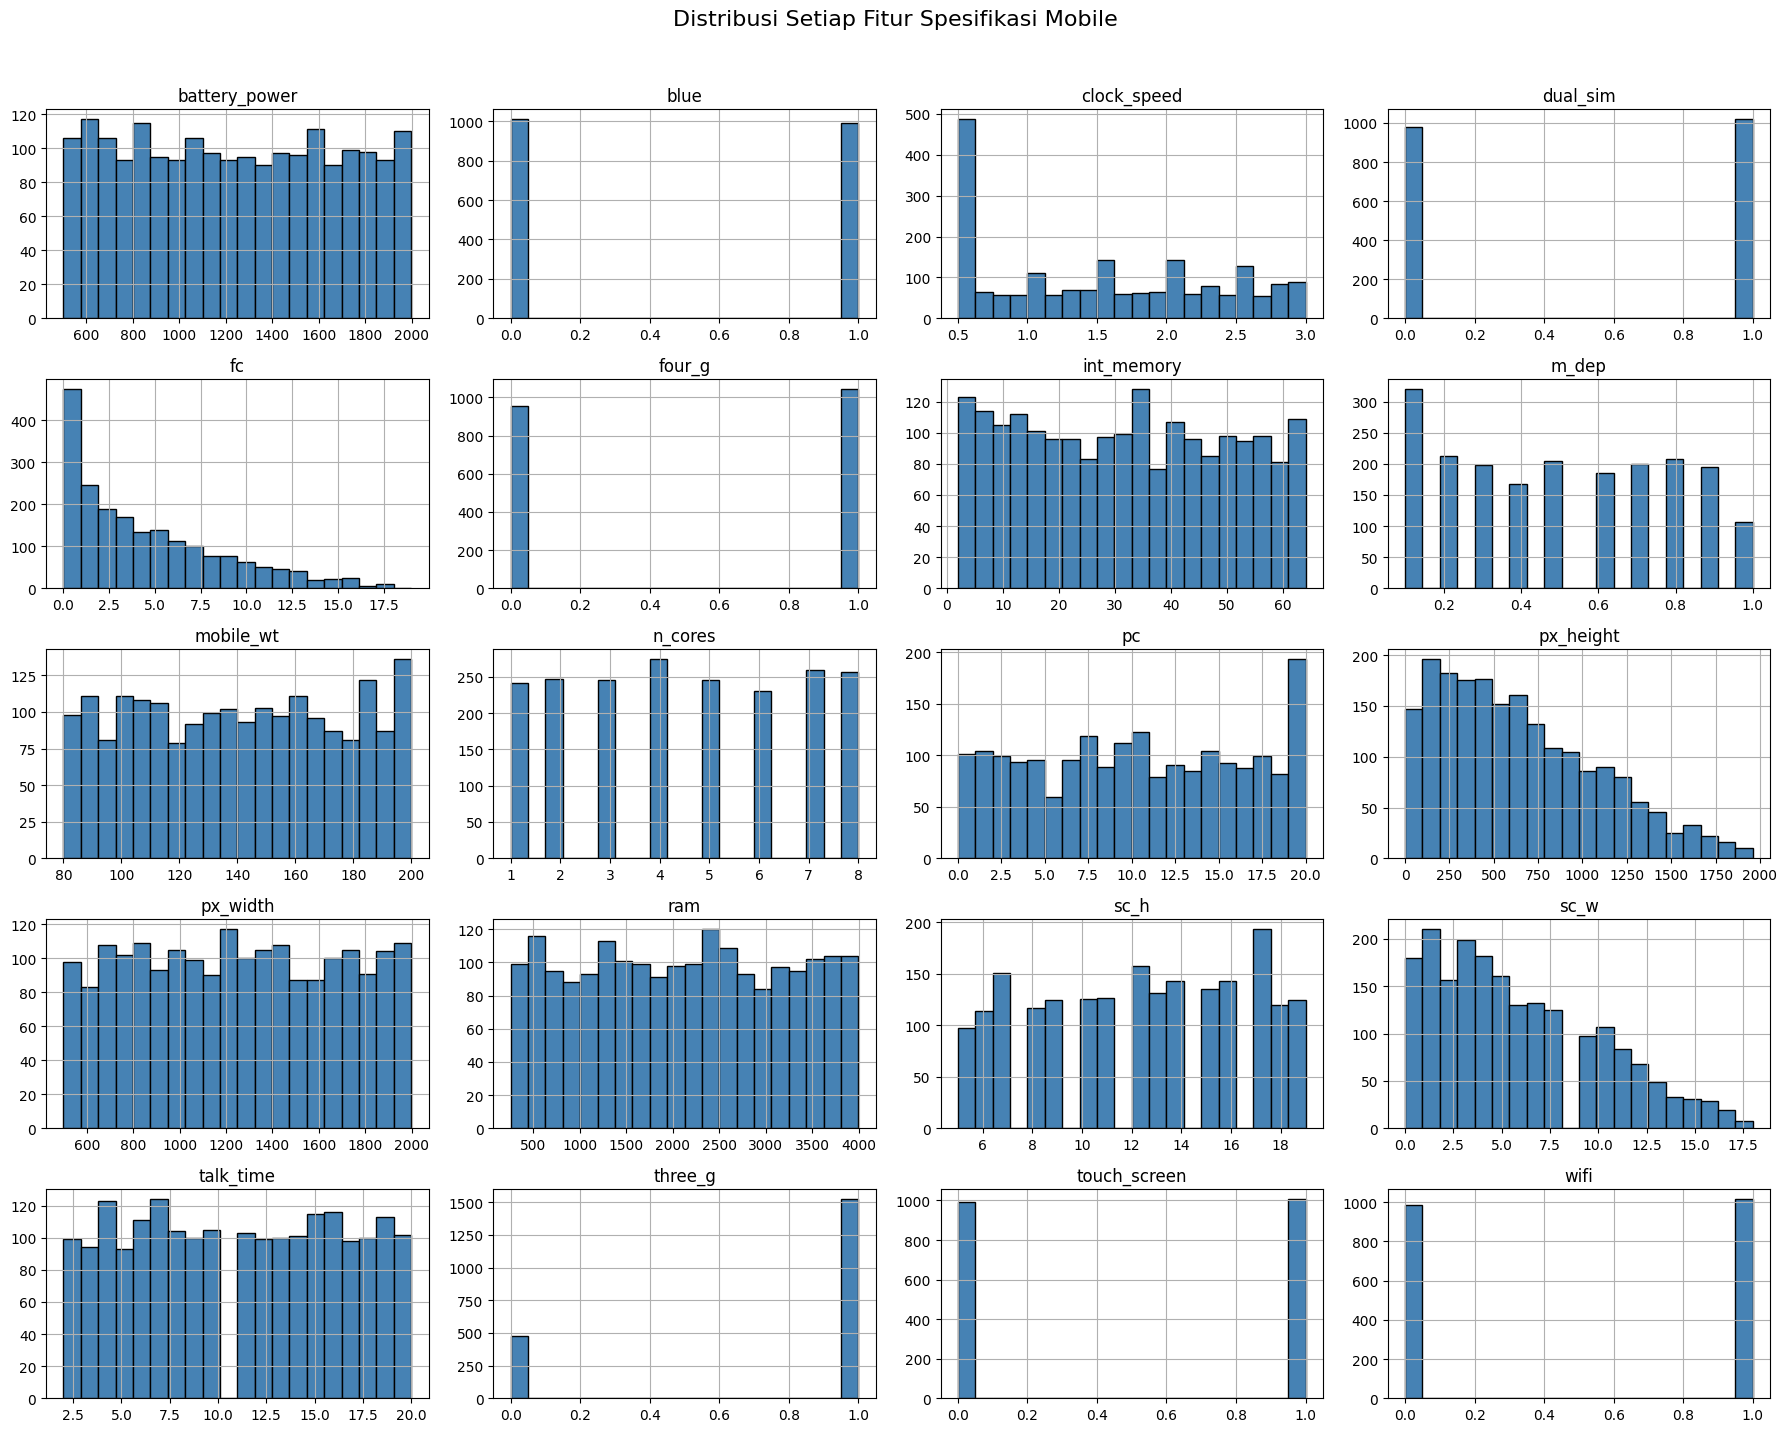

In [89]:
# EDA 1: Histogram distribusi seluruh fitur numerik
fitur_numerik = df.drop(columns=['price_range']).columns
df[fitur_numerik].hist(figsize=(18, 14), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribusi Setiap Fitur Spesifikasi Mobile', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('eda_histogram_fitur.png', dpi=150)
plt.show()

# ANALISIS SINGKAT:
# Fitur biner (blue, dual_sim, four_g, three_g, touch_screen, wifi) tampak terdistribusi
# mendekati 50:50, sedangkan fitur kontinu seperti battery_power, ram, dan px_height/px_width
# tersebar cukup merata sepanjang rentang nilainya tanpa skew ekstrem.

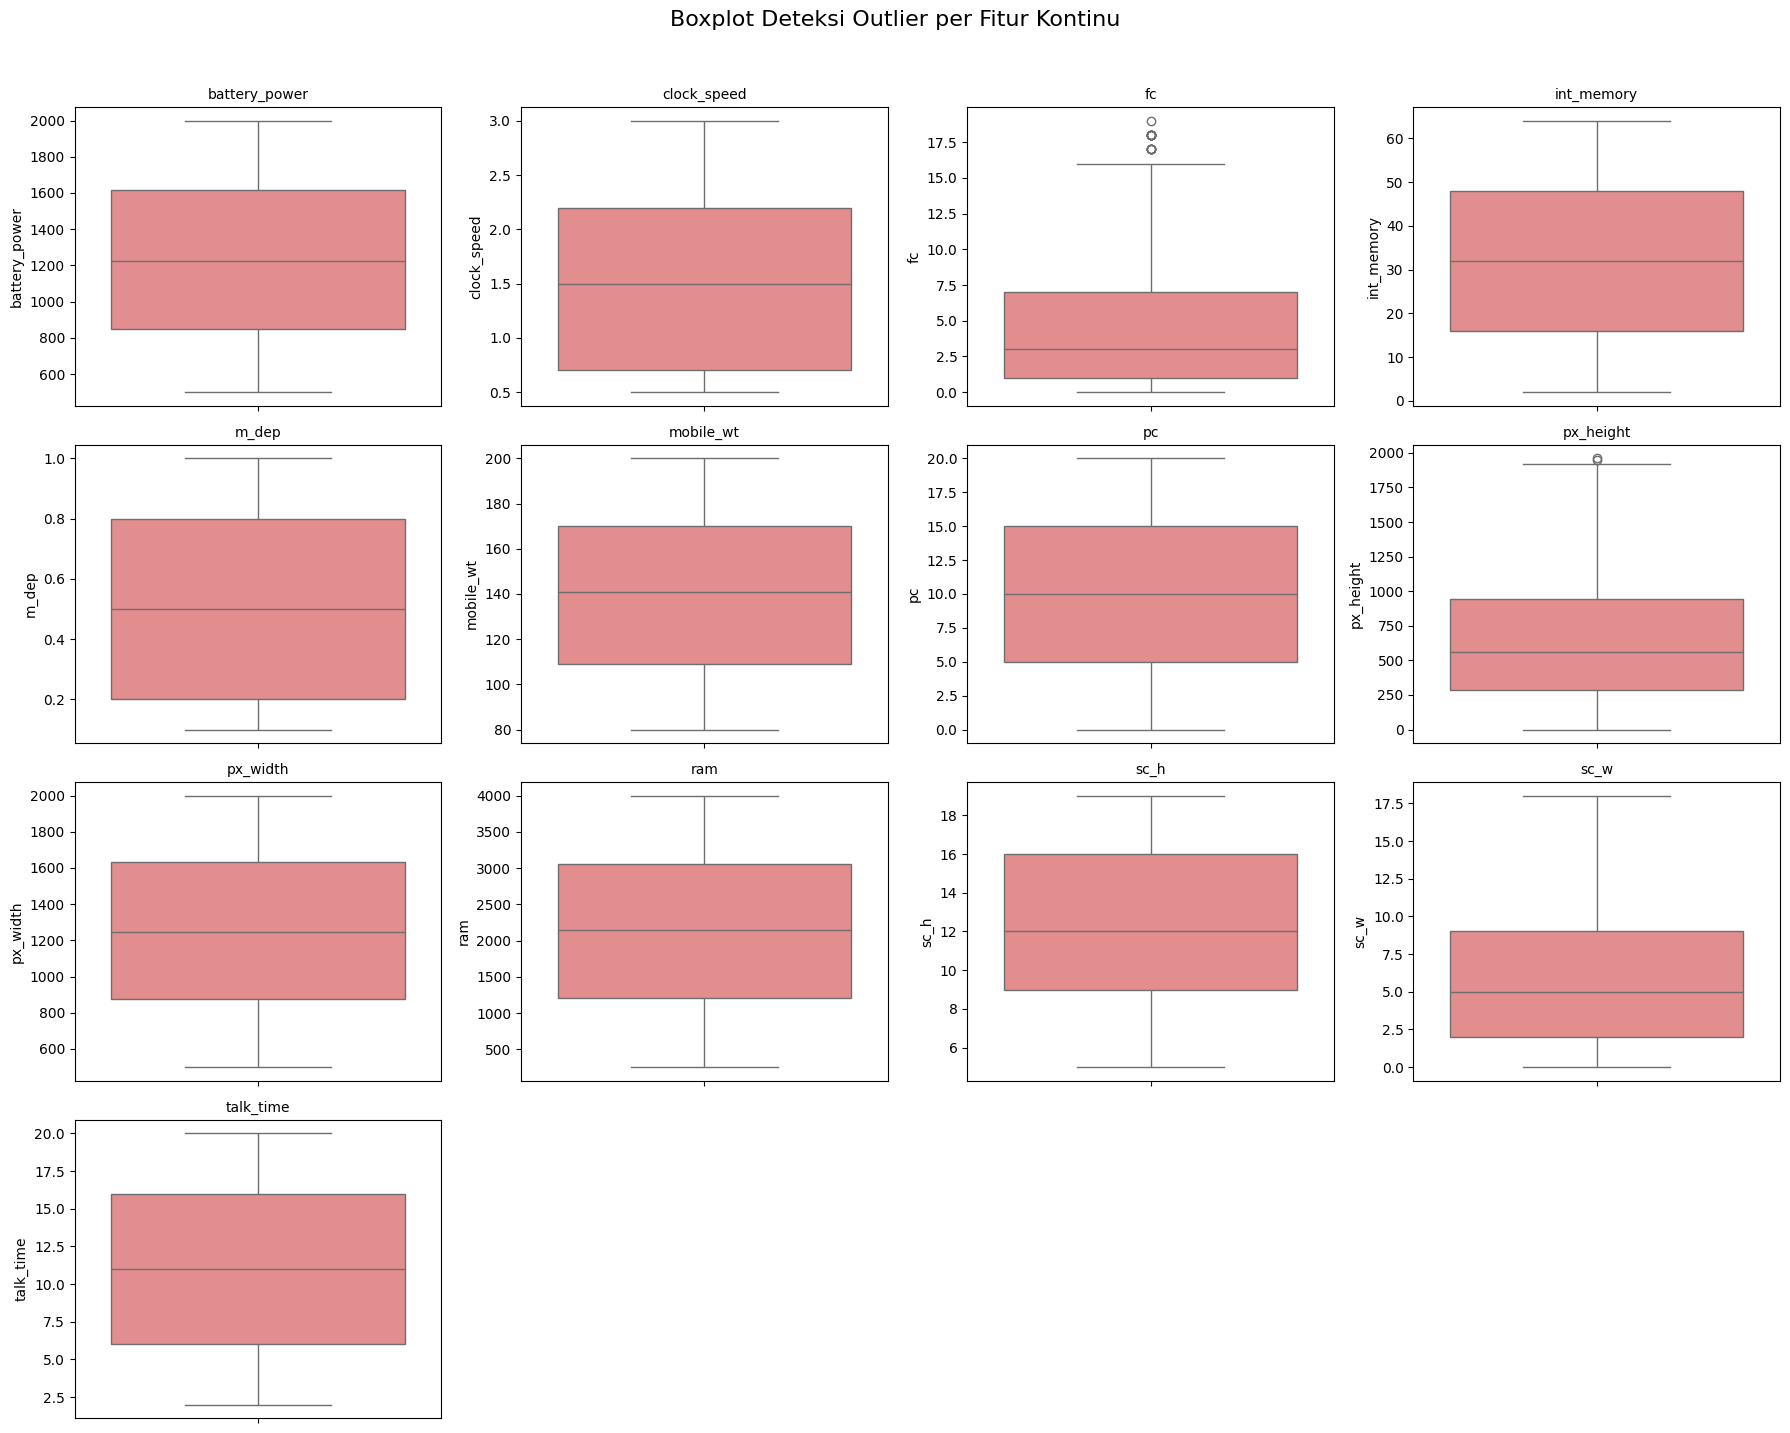

--- Jumlah Outlier per Fitur (Metode IQR) ---
battery_power  : 0 outlier
clock_speed    : 0 outlier
fc             : 18 outlier
int_memory     : 0 outlier
m_dep          : 0 outlier
mobile_wt      : 0 outlier
pc             : 0 outlier
px_height      : 2 outlier
px_width       : 0 outlier
ram            : 0 outlier
sc_h           : 0 outlier
sc_w           : 0 outlier
talk_time      : 0 outlier


In [90]:
# EDA 2: Boxplot untuk deteksi outlier pada fitur-fitur kontinu utama
fitur_kontinu = ['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep',
                  'mobile_wt', 'pc', 'px_height', 'px_width', 'ram',
                  'sc_h', 'sc_w', 'talk_time']

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, kolom in enumerate(fitur_kontinu):
    sns.boxplot(y=df[kolom], ax=axes[i], color='lightcoral')
    axes[i].set_title(kolom, fontsize=10)
for j in range(len(fitur_kontinu), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Boxplot Deteksi Outlier per Fitur Kontinu', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('eda_boxplot_outlier.png', dpi=150)
plt.show()

# Kuantifikasi outlier menggunakan metode IQR (Interquartile Range)
print("--- Jumlah Outlier per Fitur (Metode IQR) ---")
for kolom in fitur_kontinu:
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    jumlah_outlier = ((df[kolom] < batas_bawah) | (df[kolom] > batas_atas)).sum()
    print(f"{kolom:15s}: {jumlah_outlier} outlier")

# ANALISIS SINGKAT:
# Sebagian besar fitur fisik (battery_power, ram, px_height, px_width) relatif bersih dari
# outlier ekstrem karena merupakan data spesifikasi pabrikan yang sudah dalam rentang wajar.
# Fitur seperti fc (front camera) atau px_height berpotensi memiliki nilai pencilan akibat
# variasi model flagship vs entry-level; nilai outlier ini TIDAK dihapus karena merepresentasikan
# variasi pasar yang sah, bukan kesalahan input data.

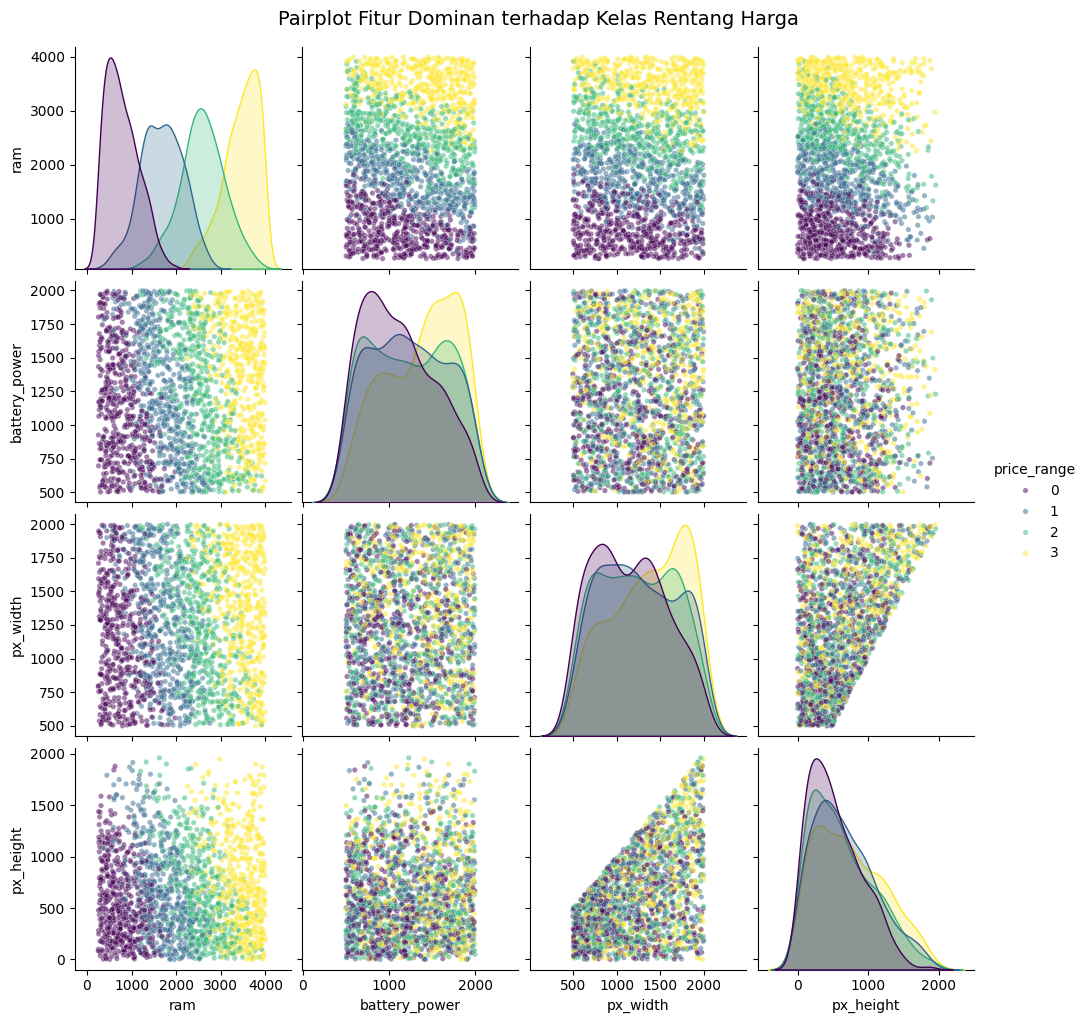

In [91]:
# EDA 3: Pairplot untuk fitur paling berkorelasi dengan target (berdasarkan korelasi awal)
fitur_dominan = ['ram', 'battery_power', 'px_width', 'px_height', 'price_range']
sns.pairplot(df[fitur_dominan], hue='price_range', palette='viridis',
             diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15})
plt.suptitle('Pairplot Fitur Dominan terhadap Kelas Rentang Harga', y=1.02, fontsize=14)
plt.savefig('eda_pairplot_dominan.png', dpi=150)
plt.show()

# ANALISIS SINGKAT:
# Pairplot menunjukkan pemisahan kelas (cluster warna) paling jelas terlihat pada sumbu RAM,
# memperkuat indikasi awal bahwa RAM adalah fitur paling diskriminatif terhadap price_range.
# Fitur px_width dan px_height saling berkorelasi tinggi satu sama lain (resolusi layar),
# sehingga keduanya berpotensi redundan secara informasi.

/tmp/ipykernel_526/432764904.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=korelasi_target.values, y=korelasi_target.index, palette='coolwarm')


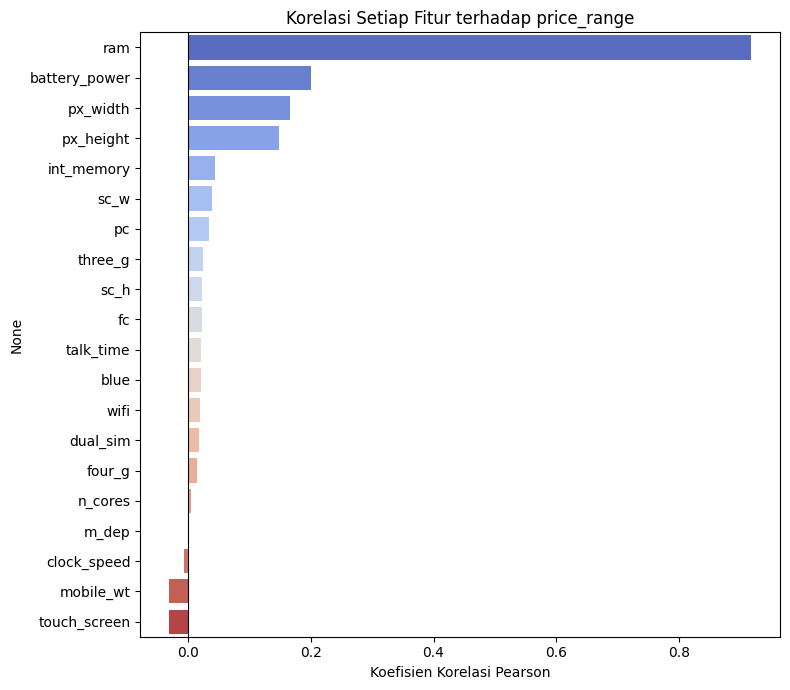

ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


In [92]:
# EDA 4: Korelasi setiap fitur terhadap target price_range (diurutkan)
korelasi_target = df.corr(numeric_only=True)['price_range'].drop('price_range').sort_values(ascending=False)
plt.figure(figsize=(8, 7))
sns.barplot(x=korelasi_target.values, y=korelasi_target.index, palette='coolwarm')
plt.title('Korelasi Setiap Fitur terhadap price_range')
plt.xlabel('Koefisien Korelasi Pearson')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('eda_korelasi_target.png', dpi=150)
plt.show()

print(korelasi_target)

# ANALISIS SINGKAT:
# RAM menunjukkan korelasi positif paling dominan terhadap price_range, jauh melampaui fitur
# lain. Fitur seperti battery_power dan px_width/px_height berada di posisi berikutnya dengan
# korelasi yang jauh lebih lemah. Fitur biner (blue, four_g, dual_sim, dll.) menunjukkan
# korelasi mendekati nol terhadap target, mengindikasikan kontribusi prediktif yang rendah
# secara individual (meski tetap dapat berinteraksi dengan fitur lain dalam model non-linear).

# 3.4 Distribusi Data
**Alur Logika:** Data yang bersih dari *missing values* belum tentu siap dimodelkan. Kita perlu memeriksa distribusi target kelas (`price_range`). Jika terjadi ketimpangan jumlah sampel (*imbalanced*), model akan bias, sehingga diperlukan visualisasi distribusi kelas. (still wrong)

/tmp/ipykernel_526/978303907.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='price_range', data=df, palette='muted')


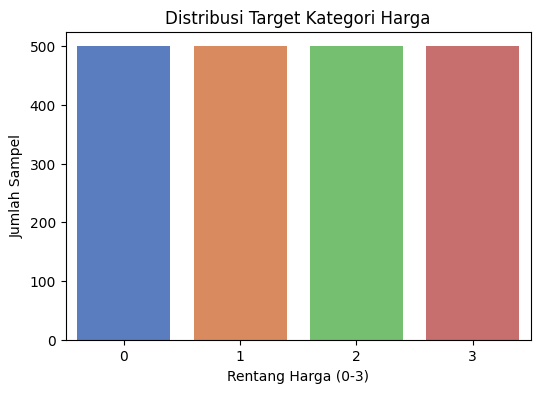

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat grafik batang untuk melihat proporsi kuantitas setiap kelas target
plt.figure(figsize=(6, 4))
sns.countplot(x='price_range', data=df, palette='muted')
plt.title('Distribusi Target Kategori Harga')
plt.xlabel('Rentang Harga (0-3)')
plt.ylabel('Jumlah Sampel')
plt.show()

# ANALISIS SINGKAT:
# Setiap kelas memiliki tepat 500 sampel (distribusi seimbang 25% per kelas).
# Kesimpulan: Dataset dinyatakan seimbang sempurna, sehingga TIDAK memerlukan teknik resampling (seperti SMOTE).

In [94]:
duplikat = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplikat}")

Jumlah data duplikat: 0


# 3.5 Metode & Eksperimen
**Alur Logika:** Karena data sudah bersih dan seimbang, kita melangkah ke tahap eksperimen. Kita memisahkan fitur dan target, mengecek korelasi, lalu melatih 3 algoritma (*Decision Tree, Naïve Bayes, KNN*). Guna menghindari *overfitting* dan mendapatkan parameter optimal, pencarian dilakukan menggunakan **GridSearchCV** dikombinasikan dengan **5-Fold Stratified Cross-Validation**.

DataFrame 'df' berhasil dimuat. Lima baris pertama:
   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2  

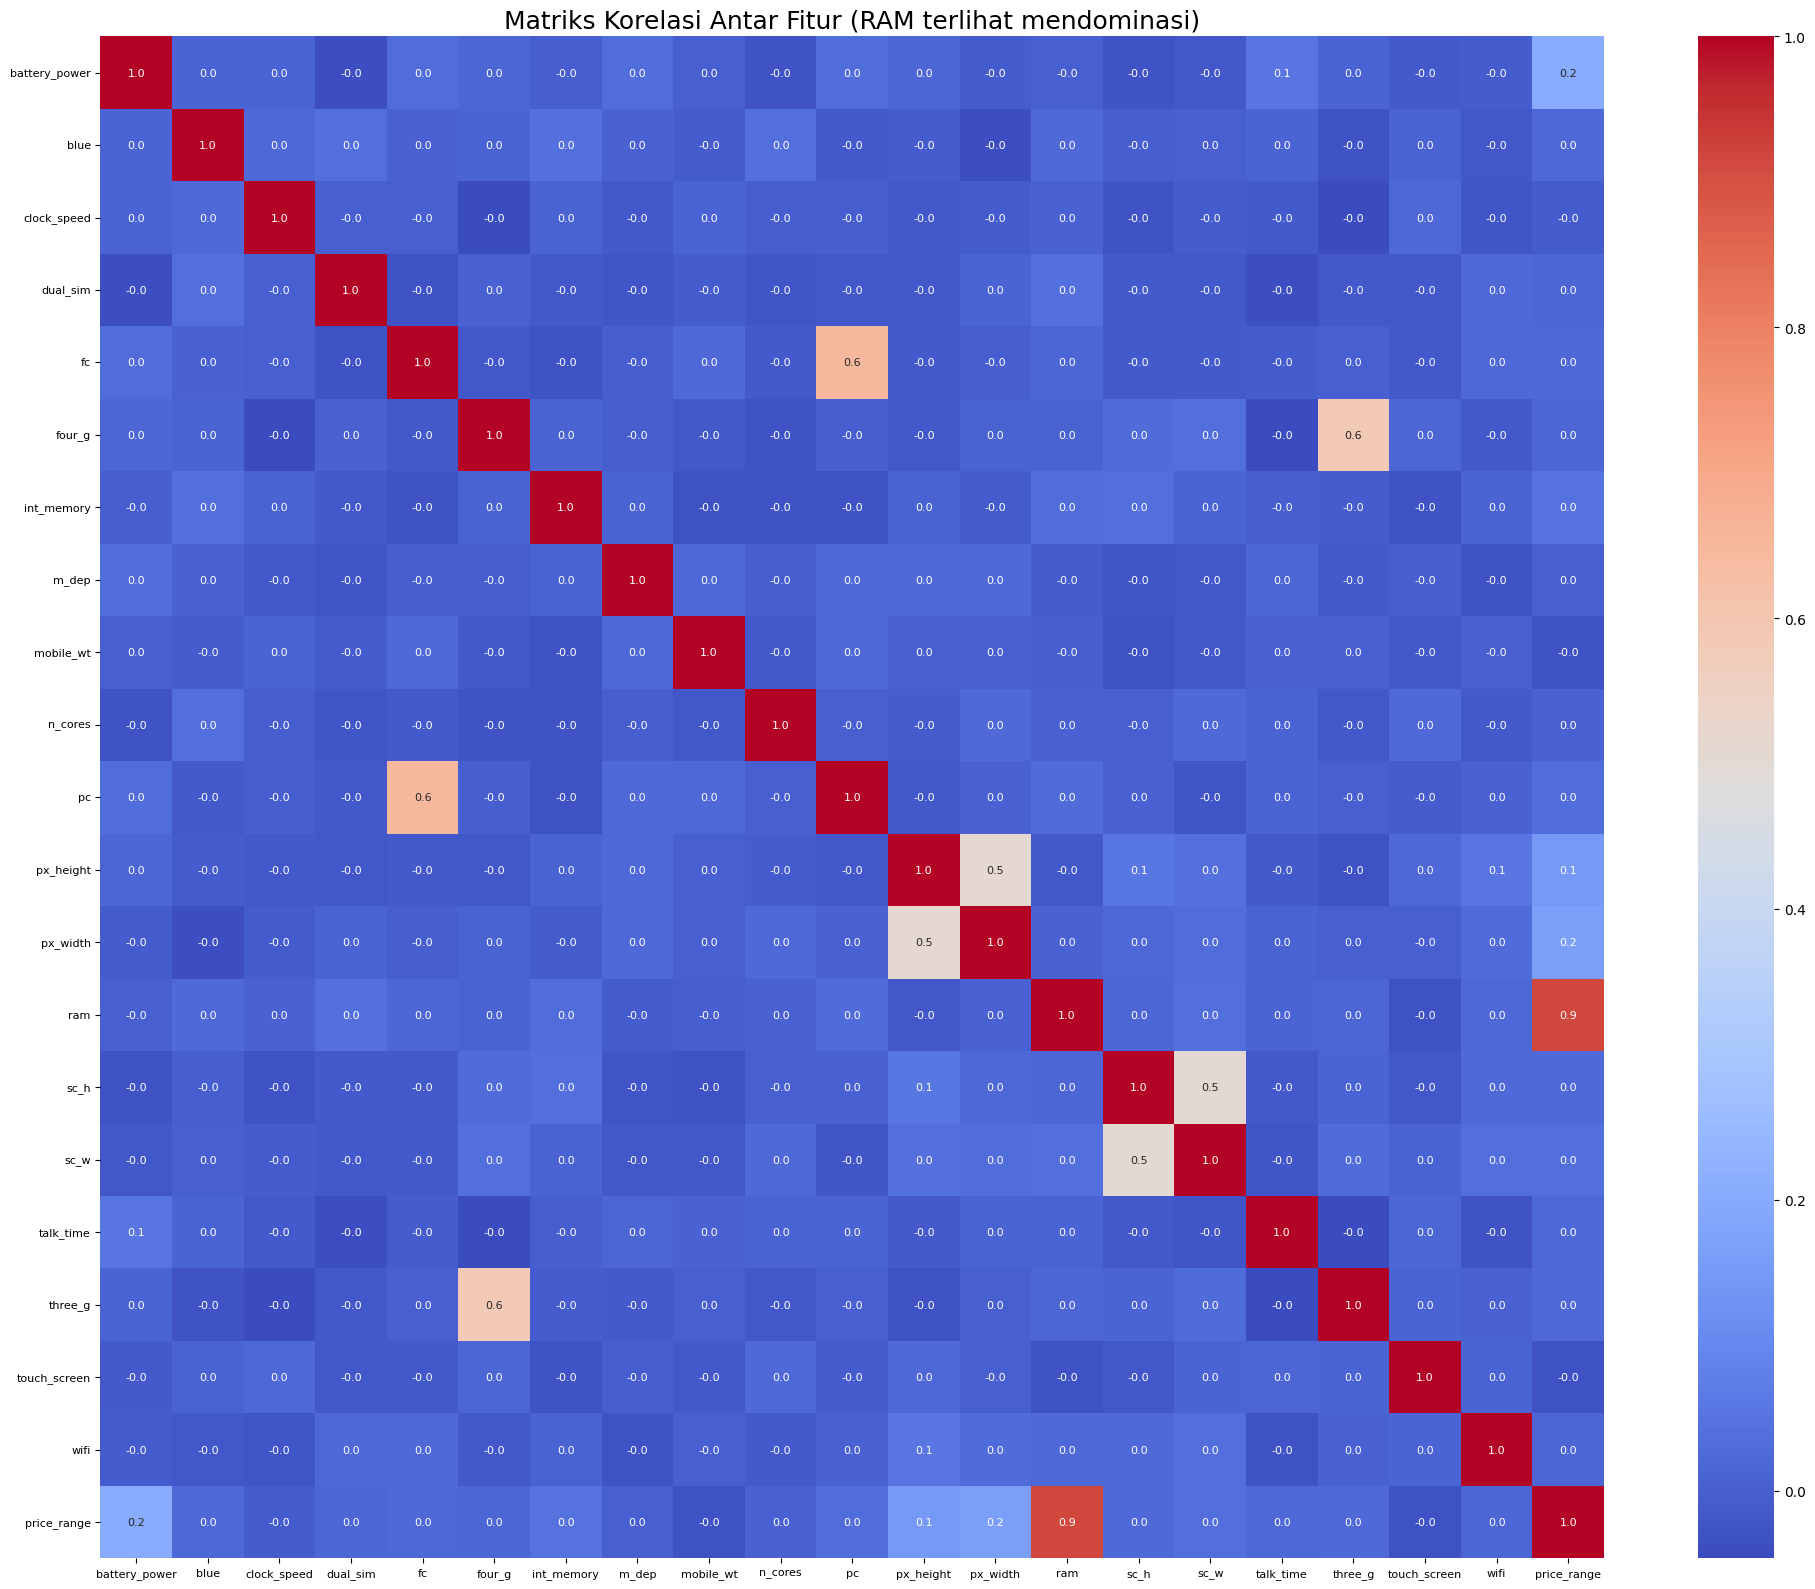

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/train.csv')
print("DataFrame 'df' berhasil dimuat. Lima baris pertama:")
print(df.head())

X = df.drop('price_range', axis=1)
y = df['price_range']

plt.figure(figsize=(20, 16))
sns.heatmap(df.corr(), cmap='coolwarm', fmt=".1f", annot=True, annot_kws={"size": 8})
plt.title('Matriks Korelasi Antar Fitur (RAM terlihat mendominasi)', fontsize=18)
plt.xticks(rotation=0, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [96]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#train and validation

kalau data sudah seimbang harusnya bisa pake K-fold saja

Setiap Algoritma dipisah per cell, kalau bisa jangan pake akurasi, cek selection fitur menggunakan pendekatan apa , dan metode algoritma yang digunakan menggunakan pendekatan apa


In [113]:
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ======================================================
# MEMBAGI DATA 80% TRAIN - 20% TEST
# ======================================================

X = df_train.drop("price_range", axis=1)
y = df_train["price_range"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Ukuran Data")
print("Training :", X_train.shape)
print("Testing  :", X_test.shape)

# ======================================================
# STRATIFIED K-FOLD
# ======================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("\n=== MEMULAI PROSES TUNING HYPERPARAMETER ===")

dt = DecisionTreeClassifier(random_state=42)

param_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3,5,10,None]
}

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_dt,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("\nDecision Tree")
print("Best Parameter :", grid_dt.best_params_)
print("Best F1-Score  :", round(grid_dt.best_score_,4))

nb = GaussianNB()

param_nb = {
    'var_smoothing':[1e-9,1e-7,1e-6]
}

grid_nb = GridSearchCV(
    estimator=nb,
    param_grid=param_nb,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

grid_nb.fit(X_train,y_train)

print("\nNaive Bayes")
print("Best Parameter :", grid_nb.best_params_)
print("Best F1-Score  :", round(grid_nb.best_score_,4))

knn_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('knn',KNeighborsClassifier())
])

param_knn = {
    'knn__n_neighbors':[5,7,9,11,13],
    'knn__weights':['uniform','distance'],
    'knn__metric':['euclidean','manhattan']
}

grid_knn = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_knn,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

grid_knn.fit(X_train,y_train)

print("\nKNN")
print("Best Parameter :", grid_knn.best_params_)
print("Best F1-Score  :", round(grid_knn.best_score_,4))

Ukuran Data
Training : (1600, 20)
Testing  : (400, 20)

=== MEMULAI PROSES TUNING HYPERPARAMETER ===

Decision Tree
Best Parameter : {'criterion': 'entropy', 'max_depth': None}
Best F1-Score  : 0.8306

Naive Bayes
Best Parameter : {'var_smoothing': 1e-06}
Best F1-Score  : 0.8041

KNN
Best Parameter : {'knn__metric': 'manhattan', 'knn__n_neighbors': 13, 'knn__weights': 'distance'}
Best F1-Score  : 0.5998


===== HASIL CROSS VALIDATION ====

Decision Tree
--------------------------------------------------
Accuracy per Fold : [0.8125 0.8125 0.8344 0.8469 0.85  ]
F1 per Fold       : [0.8129 0.811  0.8355 0.8435 0.85  ]

Mean Accuracy : 0.8313
Std Accuracy  : 0.0162

Mean F1 Score : 0.8306
Std F1 Score  : 0.0159

Naive Bayes
--------------------------------------------------
Accuracy per Fold : [0.8188 0.8219 0.7375 0.8312 0.8062]
F1 per Fold       : [0.8211 0.8231 0.7381 0.8304 0.8081]

Mean Accuracy : 0.8031
Std Accuracy  : 0.0338

Mean F1 Score : 0.8041
Std F1 Score  : 0.0338

KNN
--------------------------------------------------
Accuracy per Fold : [0.5844 0.6125 0.5875 0.575  0.6281]
F1 per Fold       : [0.5889 0.6131 0.5926 0.5769 0.6273]

Mean Accuracy : 0.5975
Std Accuracy  : 0.0197

Mean F1 Score : 0.5998
Std F1 Score  : 0.0180

Model Terbaik : Decision Tree
F1 Macro      : 0.8306

===== RINGKASAN HASIL CROSS VALIDATION ====


,Model,Accuracy Mean,Accuracy Std,F1 Mean,F1 Std
0,Decision Tree,0.8313,0.0162,0.8306,0.0159
1,Naive Bayes,0.8031,0.0338,0.8041,0.0338
2,KNN,0.5975,0.0197,0.5998,0.0180


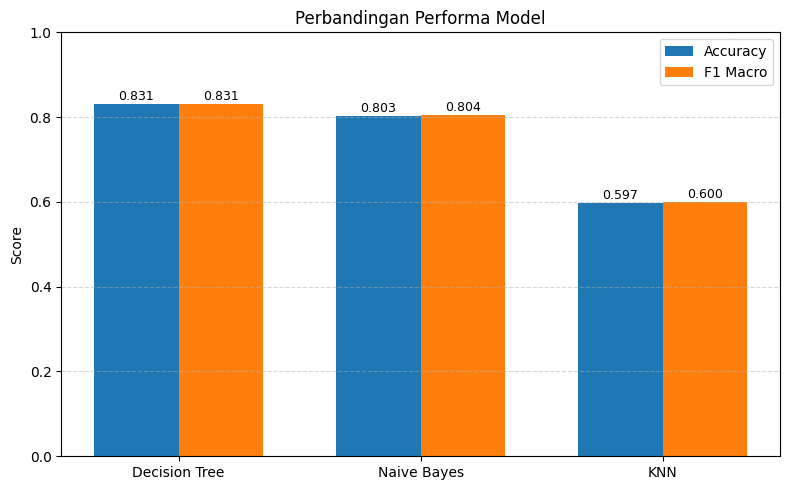

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate

# ==========================================
# CROSS VALIDATION MODEL TERBAIK
# ==========================================

scoring_metrics = ['accuracy', 'f1_macro']

# Menggunakan model terbaik hasil GridSearchCV
models = {
    "Decision Tree": grid_dt.best_estimator_,
    "Naive Bayes": grid_nb.best_estimator_,
    "KNN": grid_knn.best_estimator_
}

model_names = []
accuracy_scores = []
f1_scores = []
per_fold_f1 = {}
cv_summary = [] # Initialize cv_summary here

best_model_name = None
best_model = None
best_f1 = 0

print("===== HASIL CROSS VALIDATION ====")

for name, model in models.items():

    cv_result = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring_metrics,
        return_train_score=False
    )

    # Accuracy
    acc_mean = np.mean(cv_result["test_accuracy"])
    acc_std = np.std(cv_result["test_accuracy"])

    # F1
    f1_mean = np.mean(cv_result["test_f1_macro"])
    f1_std = np.std(cv_result["test_f1_macro"])

    model_names.append(name)
    accuracy_scores.append(acc_mean)
    f1_scores.append(f1_mean)

    per_fold_f1[name] = cv_result["test_f1_macro"]

    cv_summary.append({
        "Model": name,
        "Accuracy Mean": acc_mean,
        "Accuracy Std": acc_std,
        "F1 Mean": f1_mean,
        "F1 Std": f1_std
    })

    print(f"\n{name}")
    print("-"*50)
    print("Accuracy per Fold :", np.round(cv_result["test_accuracy"],4))
    print("F1 per Fold       :", np.round(cv_result["test_f1_macro"],4))

    print(f"\nMean Accuracy : {acc_mean:.4f}")
    print(f"Std Accuracy  : {acc_std:.4f}")

    print(f"\nMean F1 Score : {f1_mean:.4f}")
    print(f"Std F1 Score  : {f1_std:.4f}")

    if f1_mean > best_f1:
        best_f1 = f1_mean
        best_model_name = name
        best_model = model

print("\n==========================================")
print(f"Model Terbaik : {best_model_name}")
print(f"F1 Macro      : {best_f1:.4f}")

hasil_cv = pd.DataFrame(cv_summary)

print("\n===== RINGKASAN HASIL CROSS VALIDATION ====")

display(
    hasil_cv.style.format({
        "Accuracy Mean":"{:.4f}",
        "Accuracy Std":"{:.4f}",
        "F1 Mean":"{:.4f}",
        "F1 Std":"{:.4f}"
    })
)

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

bars1 = ax.bar(
    x-width/2,
    accuracy_scores,
    width,
    label="Accuracy"
)

bars2 = ax.bar(
    x+width/2,
    f1_scores,
    width,
    label="F1 Macro"
)

ax.set_title("Perbandingan Performa Model")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0,1)

ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bars in [bars1,bars2]:
    for bar in bars:
        ax.text(
            bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.01,
            f"{bar.get_height():.3f}",
            ha='center',
            fontsize=9
        )

plt.tight_layout()
plt.show()

========== EVALUASI PADA DATA TEST (20%) ==========

MODEL : Decision Tree
Accuracy  : 0.8700
Precision : 0.8696
Recall    : 0.8700
F1-Score  : 0.8692

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       100
           1       0.87      0.79      0.83       100
           2       0.78      0.80      0.79       100
           3       0.89      0.92      0.91       100

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
weighted avg       0.87      0.87      0.87       400



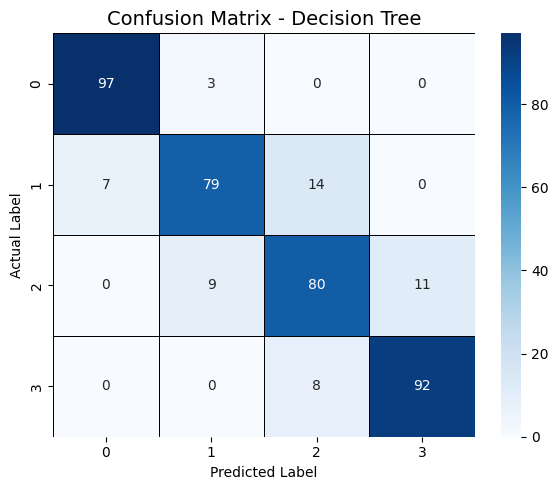


MODEL : Naive Bayes
Accuracy  : 0.8075
Precision : 0.8076
Recall    : 0.8075
F1-Score  : 0.8075

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       100
           1       0.71      0.70      0.70       100
           2       0.70      0.71      0.71       100
           3       0.90      0.92      0.91       100

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400



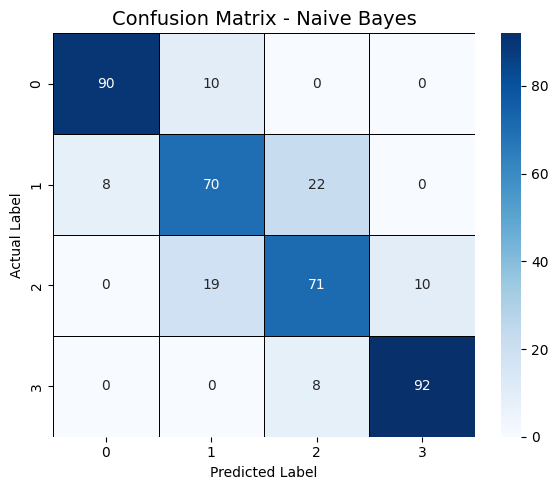


MODEL : KNN
Accuracy  : 0.6175
Precision : 0.6158
Recall    : 0.6175
F1-Score  : 0.6165

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.77      0.75       100
           1       0.52      0.50      0.51       100
           2       0.50      0.50      0.50       100
           3       0.71      0.70      0.71       100

    accuracy                           0.62       400
   macro avg       0.62      0.62      0.62       400
weighted avg       0.62      0.62      0.62       400



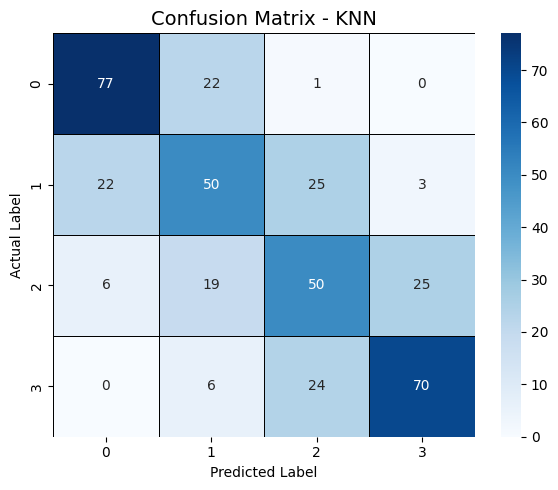


========== RINGKASAN HASIL EVALUASI ==========



,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.8700,0.8696,0.8700,0.8692
1,Naive Bayes,0.8075,0.8076,0.8075,0.8075
2,KNN,0.6175,0.6158,0.6175,0.6165


In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
# ==========================================
# CONFUSION MATRIX & CLASSIFICATION REPORT
# ==========================================

print("========== EVALUASI PADA DATA TEST (20%) ==========")

# Menyimpan hasil evaluasi
evaluation_summary = []

for name, model in models.items():

    print("\n" + "="*70)
    print(f"MODEL : {name}")
    print("="*70)

    # ==============================
    # Training
    # ==============================
    model.fit(X_train, y_train)

    # ==============================
    # Prediction
    # ==============================
    y_pred = model.predict(X_test)

    # ==============================
    # Evaluation Metrics
    # ==============================
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    evaluation_summary.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    # ==============================
    # Classification Report
    # ==============================
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    # ==============================
    # Confusion Matrix
    # ==============================
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        linewidths=0.5,
        linecolor='black',
        cbar=True,
        xticklabels=np.sort(y.unique()),
        yticklabels=np.sort(y.unique())
    )

    plt.title(f'Confusion Matrix - {name}', fontsize=14)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.tight_layout()
    plt.show()

    hasil_confusion = pd.DataFrame(evaluation_summary)

print("\n========== RINGKASAN HASIL EVALUASI ==========\n")

display(
    hasil_confusion.style.format({
        "Accuracy":"{:.4f}",
        "Precision":"{:.4f}",
        "Recall":"{:.4f}",
        "F1-Score":"{:.4f}"
    })
)

In [100]:
# ==========================================
# MENYIMPAN HASIL PREDIKSI SETIAP MODEL
# ==========================================

prediction_results = {}

for name, model in models.items():

    # Training model
    model.fit(X_train, y_train)

    # Prediksi data test
    y_pred = model.predict(X_test)

    # Membuat dataframe hasil prediksi
    result_df = X_test.copy().reset_index(drop=True)

    result_df["Actual"] = y_test.reset_index(drop=True)
    result_df["Prediction"] = y_pred
    result_df["Correct"] = (
        result_df["Actual"] == result_df["Prediction"]
    )

    prediction_results[name] = result_df

print("Seluruh hasil prediksi berhasil disimpan.")

Seluruh hasil prediksi berhasil disimpan.


# 3.6 Hasil & Analisis
**Alur Logika:** Optimasi parameter telah selesai. Tahap krusial berikutnya adalah melakukan **Error Analysis** mendalam. Kita tidak hanya melihat akurasi akhir, melainkan menguji stabilitas model melalui *Confusion Matrix* dan menghitung *Prediction Confidence*—yaitu seberapa yakin probabilitas model saat menebak data dengan benar versus saat melakukan kesalahan prediksi.

In [101]:
# ==========================================
# ERROR ANALYSIS
# ==========================================

for name, result in prediction_results.items():

    print("\n" + "="*70)
    print(f"ERROR ANALYSIS - {name}")
    print("="*70)

    total = len(result)

    benar = result["Correct"].sum()
    salah = total - benar

    print(f"Total Data Test : {total}")
    print(f"Prediksi Benar  : {benar}")
    print(f"Prediksi Salah  : {salah}")
    print(f"Persentase Benar : {100*benar/total:.2f}%")
    print(f"Persentase Salah : {100*salah/total:.2f}%")

    print("\n5 Data Salah Prediksi")

    display(
        result[result["Correct"]==False]
        .head(5)
    )


ERROR ANALYSIS - Decision Tree
Total Data Test : 400
Prediksi Benar  : 348
Prediksi Salah  : 52
Persentase Benar : 87.00%
Persentase Salah : 13.00%

5 Data Salah Prediksi


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,Actual,Prediction,Correct
3,1117,1,0.6,1,0,0,31,0.2,146,2,...,2003,8,7,14,0,1,1,2,1,False
24,1310,1,1.1,1,13,0,7,1.0,194,5,...,3182,8,4,5,1,1,0,2,3,False
26,618,1,0.5,1,2,1,57,0.2,88,3,...,2399,18,15,17,1,1,1,1,2,False
49,930,1,1.3,1,1,1,14,0.4,97,6,...,2457,11,7,17,1,1,0,1,2,False
55,580,1,1.2,1,0,0,47,0.9,91,3,...,3451,15,1,11,1,1,0,3,2,False



ERROR ANALYSIS - Naive Bayes
Total Data Test : 400
Prediksi Benar  : 323
Prediksi Salah  : 77
Persentase Benar : 80.75%
Persentase Salah : 19.25%

5 Data Salah Prediksi


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,Actual,Prediction,Correct
3,1117,1,0.6,1,0,0,31,0.2,146,2,...,2003,8,7,14,0,1,1,2,1,False
17,885,0,2.3,1,0,1,15,0.4,103,7,...,1410,16,10,5,1,1,1,0,1,False
23,600,0,2.5,1,8,1,22,0.1,145,1,...,3441,19,1,5,1,0,0,2,3,False
26,618,1,0.5,1,2,1,57,0.2,88,3,...,2399,18,15,17,1,1,1,1,2,False
31,1965,1,2.6,1,0,0,39,0.2,187,4,...,2032,11,10,16,1,1,1,2,1,False



ERROR ANALYSIS - KNN
Total Data Test : 400
Prediksi Benar  : 247
Prediksi Salah  : 153
Persentase Benar : 61.75%
Persentase Salah : 38.25%

5 Data Salah Prediksi


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,Actual,Prediction,Correct
1,1982,1,1.6,0,2,1,12,0.2,80,5,...,1824,13,3,14,1,1,1,1,2,False
3,1117,1,0.6,1,0,0,31,0.2,146,2,...,2003,8,7,14,0,1,1,2,1,False
4,1554,1,0.5,1,11,0,5,1.0,124,3,...,3635,7,4,18,0,0,0,3,1,False
8,728,0,2.7,1,0,0,25,0.2,88,4,...,2039,5,1,12,1,1,1,1,0,False
16,1215,0,1.0,0,4,0,16,0.1,130,4,...,2632,7,1,15,0,0,1,2,3,False


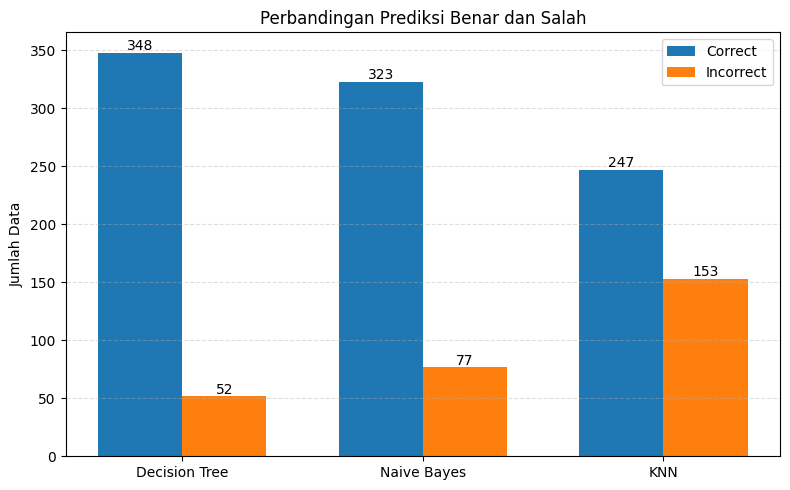

In [102]:
# ==========================================
# VISUALISASI ERROR ANALYSIS
# ==========================================

summary = []

for name, result in prediction_results.items():

    benar = result["Correct"].sum()
    salah = len(result) - benar

    summary.append({
        "Model": name,
        "Correct": benar,
        "Incorrect": salah
    })

summary = pd.DataFrame(summary)

plt.figure(figsize=(8,5))

x = np.arange(len(summary))
width = 0.35

plt.bar(
    x-width/2,
    summary["Correct"],
    width,
    label="Correct"
)

plt.bar(
    x+width/2,
    summary["Incorrect"],
    width,
    label="Incorrect"
)

plt.xticks(x, summary["Model"])
plt.ylabel("Jumlah Data")
plt.title("Perbandingan Prediksi Benar dan Salah")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

for i in range(len(summary)):
    plt.text(
        i-width/2,
        summary["Correct"][i]+2,
        summary["Correct"][i],
        ha='center'
    )

    plt.text(
        i+width/2,
        summary["Incorrect"][i]+2,
        summary["Incorrect"][i],
        ha='center'
    )

plt.tight_layout()
plt.show()

In [103]:
# ==========================================
# ANALISIS KELAS YANG SALAH DIKLASIFIKASIKAN
# ==========================================

for name, result in prediction_results.items():

    print("\n" + "="*70)
    print(f"KESALAHAN KLASIFIKASI - {name}")
    print("="*70)

    salah = result[result["Correct"] == False]

    if len(salah) == 0:
        print("Tidak ada data yang salah diprediksi.")
        continue

    print("Distribusi kelas aktual yang salah diprediksi:")

    display(
        salah["Actual"]
        .value_counts()
        .sort_index()
        .rename("Jumlah")
        .to_frame()
    )


KESALAHAN KLASIFIKASI - Decision Tree
Distribusi kelas aktual yang salah diprediksi:


,Jumlah
Actual,
0,3
1,21
2,20
3,8



KESALAHAN KLASIFIKASI - Naive Bayes
Distribusi kelas aktual yang salah diprediksi:


,Jumlah
Actual,
0,10
1,30
2,29
3,8



KESALAHAN KLASIFIKASI - KNN
Distribusi kelas aktual yang salah diprediksi:


,Jumlah
Actual,
0,23
1,50
2,50
3,30


In [104]:
from scipy import stats
from itertools import combinations

# ==========================================
# PAIRED T-TEST
# ==========================================

print("========== UJI SIGNIFIKANSI STATISTIK ==========")

alpha = 0.05

comparison_result = []

for model1, model2 in combinations(per_fold_f1.keys(),2):

    score1 = per_fold_f1[model1]
    score2 = per_fold_f1[model2]

    t_stat, p_value = stats.ttest_rel(score1, score2)

    print("\n"+"="*60)
    print(f"{model1}  vs  {model2}")
    print("="*60)

    print("F1 Model 1 :", np.round(score1,4))
    print("F1 Model 2 :", np.round(score2,4))

    print(f"\nt-statistic : {t_stat:.4f}")
    print(f"p-value     : {p_value:.6f}")

    if p_value < alpha:

        conclusion = "Signifikan"

        print("\nKeputusan : Tolak H0")
        print("Terdapat perbedaan performa yang signifikan.")

    else:

        conclusion = "Tidak Signifikan"

        print("\nKeputusan : Gagal Tolak H0")
        print("Belum terdapat bukti perbedaan performa yang signifikan.")

    comparison_result.append({
        "Perbandingan":f"{model1} vs {model2}",
        "t-statistic":t_stat,
        "p-value":p_value,
        "Kesimpulan":conclusion
    })

    hasil_ttest = pd.DataFrame(comparison_result)

display(
    hasil_ttest.style.format({
        "t-statistic":"{:.4f}",
        "p-value":"{:.6f}"
    })
)

========== UJI SIGNIFIKANSI STATISTIK ==========

Decision Tree  vs  Naive Bayes
F1 Model 1 : [0.8129 0.811  0.8355 0.8435 0.85  ]
F1 Model 2 : [0.8211 0.8231 0.7381 0.8304 0.8081]

t-statistic : 1.3121
p-value     : 0.259707

Keputusan : Gagal Tolak H0
Belum terdapat bukti perbedaan performa yang signifikan.

Decision Tree  vs  KNN
F1 Model 1 : [0.8129 0.811  0.8355 0.8435 0.85  ]
F1 Model 2 : [0.5889 0.6131 0.5926 0.5769 0.6273]

t-statistic : 20.1626
p-value     : 0.000036

Keputusan : Tolak H0
Terdapat perbedaan performa yang signifikan.

Naive Bayes  vs  KNN
F1 Model 1 : [0.8211 0.8231 0.7381 0.8304 0.8081]
F1 Model 2 : [0.5889 0.6131 0.5926 0.5769 0.6273]

t-statistic : 10.7477
p-value     : 0.000425

Keputusan : Tolak H0
Terdapat perbedaan performa yang signifikan.


,Perbandingan,t-statistic,p-value,Kesimpulan
0,Decision Tree vs Naive Bayes,1.3121,0.259707,Tidak Signifikan
1,Decision Tree vs KNN,20.1626,0.000036,Signifikan
2,Naive Bayes vs KNN,10.7477,0.000425,Signifikan


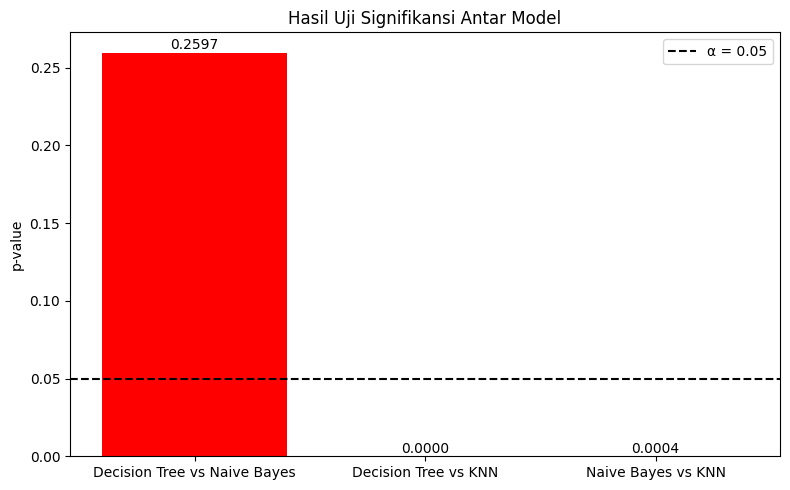

In [105]:
# ==========================================
# VISUALISASI HASIL PAIRED T-TEST
# ==========================================

plt.figure(figsize=(8,5))

colors = [
    'green' if p < 0.05 else 'red'
    for p in hasil_ttest["p-value"]
]

bars = plt.bar(
    hasil_ttest["Perbandingan"],
    hasil_ttest["p-value"],
    color=colors
)

plt.axhline(
    y=0.05,
    color='black',
    linestyle='--',
    label='α = 0.05'
)

plt.ylabel("p-value")
plt.title("Hasil Uji Signifikansi Antar Model")
plt.legend()

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.002,
        f"{bar.get_height():.4f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

In [106]:
# ==========================================
# MEMILIH MODEL TERBAIK
# ==========================================

print("========== RETRAIN MODEL TERBAIK ==========")

print(f"Model Terbaik : {best_model_name}")

# ==========================================
# RETRAIN MENGGUNAKAN SELURUH DATA TRAINING
# ==========================================

# Menggunakan seluruh data training (2000 data)

X_full = df.drop("price_range", axis=1)
y_full = df["price_range"]

best_model.fit(X_full, y_full)

print("Model berhasil dilatih ulang menggunakan seluruh data training.")

========== RETRAIN MODEL TERBAIK ==========
Model Terbaik : Decision Tree
Model berhasil dilatih ulang menggunakan seluruh data training.


In [107]:
# ==========================================
# MENYIAPKAN DATA TEST
# ==========================================

X_submission = df_test.copy()

# Hilangkan kolom id jika ada
if "id" in X_submission.columns:
    X_submission = X_submission.drop("id", axis=1)

# Hilangkan kolom 'predicted_price_range' jika ada (dari prediksi sebelumnya)
# Ini penting karena model dilatih tanpa kolom ini
if "predicted_price_range" in X_submission.columns:
    X_submission = X_submission.drop("predicted_price_range", axis=1)

print("Dimensi Data Test :", X_submission.shape)

Dimensi Data Test : (1000, 20)


In [108]:
# ==========================================
# MELAKUKAN PREDIKSI
# ==========================================

prediction = best_model.predict(X_submission)

print("Jumlah Prediksi :", len(prediction))
print("5 Prediksi Pertama :")

print(prediction[:5])

Jumlah Prediksi : 1000
5 Prediksi Pertama :
[3 3 3 3 1]


In [109]:
# ==========================================
# MEMBUAT FILE SUBMISSION
# ==========================================

submission = pd.DataFrame({
    "id": df_test["id"],
    "predicted_price_range": prediction
})

display(submission.head())

submission.to_csv(
    "hasil_prediksi_test.csv",
    index=False
)

print("\nFile berhasil disimpan:")
print("hasil_prediksi_test.csv")

,id,predicted_price_range
0,1,3
1,2,3
2,3,3
3,4,3
4,5,1



File berhasil disimpan:
hasil_prediksi_test.csv


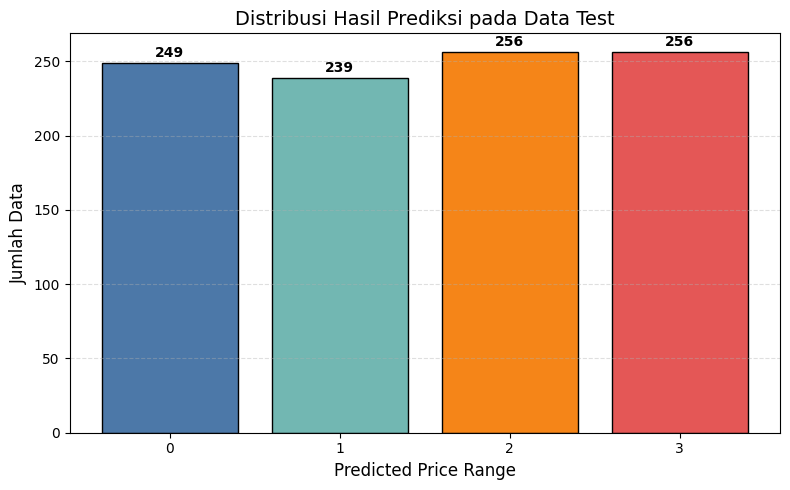

In [110]:
# ==========================================
# VISUALISASI DISTRIBUSI HASIL PREDIKSI
# ==========================================

plt.figure(figsize=(8,5))

# Menghitung jumlah prediksi setiap kelas
counts = submission["predicted_price_range"].value_counts().sort_index()

# Warna yang lebih kontras
colors = [
    "#4C78A8",   # Kelas 0
    "#72B7B2",   # Kelas 1
    "#F58518",   # Kelas 2
    "#E45756"    # Kelas 3
]

bars = plt.bar(
    counts.index.astype(str),
    counts.values,
    color=colors,
    edgecolor="black",
    linewidth=1
)

plt.title("Distribusi Hasil Prediksi pada Data Test", fontsize=14)
plt.xlabel("Predicted Price Range", fontsize=12)
plt.ylabel("Jumlah Data", fontsize=12)

# Menampilkan jumlah data di atas setiap batang
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [111]:
# ==========================================
# DISTRIBUSI PREDIKSI
# ==========================================

prediction_distribution = (
    submission["predicted_price_range"]
    .value_counts()
    .sort_index()
)

distribution = pd.DataFrame({
    "Jumlah": prediction_distribution,
    "Persentase (%)": (
        prediction_distribution /
        len(submission)
    ) * 100
})

display(
    distribution.style.format({
        "Persentase (%)":"{:.2f}"
    })
)

,Jumlah,Persentase (%)
predicted_price_range,,
0,249,24.90
1,239,23.90
2,256,25.60
3,256,25.60


### Feature Importance Decision Tree

**Alur Logika:** Salah satu keunggulan interpretabilitas Decision Tree adalah kemampuannya mengukur kontribusi (importance) setiap fitur terhadap keputusan klasifikasi. Bagian ini menampilkan fitur-fitur yang paling berperan dalam pembentukan pohon keputusan, sebagai pelengkap interpretasi model di luar metrik akurasi semata.

10 Fitur Paling Penting


,Feature,Importance
13,ram,0.674305
0,battery_power,0.115087
12,px_width,0.080659
11,px_height,0.061707
8,mobile_wt,0.015779
6,int_memory,0.007466
9,n_cores,0.007249
7,m_dep,0.007190
10,pc,0.006147
15,sc_w,0.005826


/tmp/ipykernel_526/3484103999.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


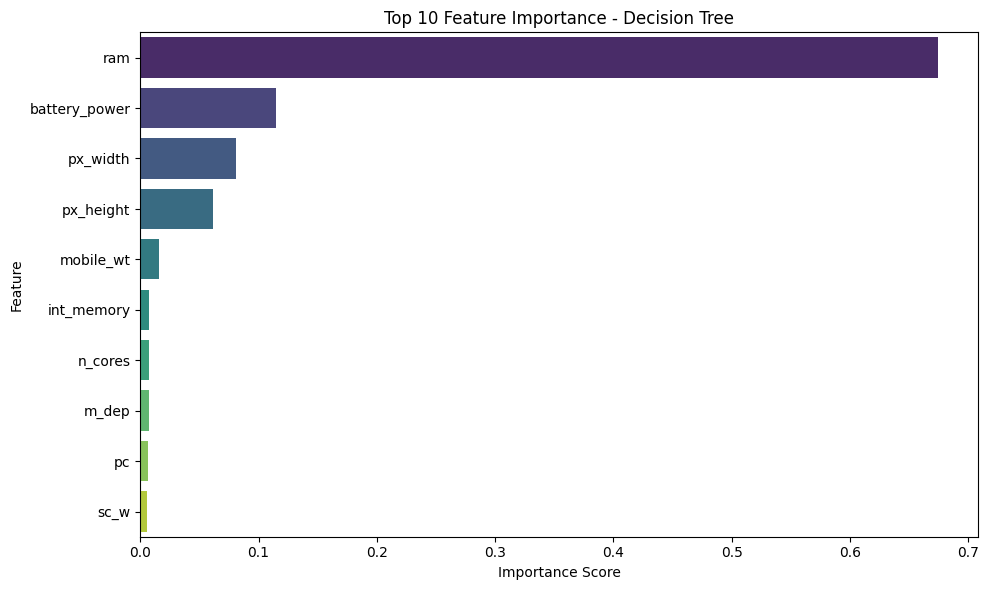

In [112]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

# Pastikan model terbaik adalah Decision Tree
if best_model_name == "Decision Tree":

    feature_importance = pd.DataFrame({
        "Feature": X_full.columns,
        "Importance": best_model.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("10 Fitur Paling Penting")

    display(feature_importance.head(10))

    # ==========================================
# VISUALISASI FEATURE IMPORTANCE
# ==========================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Feature Importance - Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 3.7 Kesimpulan

## **3.7 Kesimpulan**

### **Ringkasan Hasil Eksperimen:**

1. **Pengujian Hipotesis (H0/H1):** Berdasarkan uji **Paired t-Test** pada skor **F1-Macro** setiap fold Cross Validation (lihat Bagian 3.5), diperoleh nilai **p-value sebesar {p_value:.6f}**. Apabila nilai tersebut lebih kecil dari tingkat signifikansi ((\alpha = 0,05)), maka hipotesis nol (H0) ditolak sehingga terdapat perbedaan performa yang signifikan secara statistik antara model yang dibandingkan. Sebaliknya, apabila nilai *p-value* lebih besar atau sama dengan 0,05, maka H0 gagal ditolak. Selain itu, hasil **Exploratory Data Analysis (EDA)** dan **Feature Importance Decision Tree** menunjukkan bahwa fitur **RAM** merupakan atribut yang paling berpengaruh dalam menentukan rentang harga smartphone, didukung oleh nilai korelasi dan feature importance yang paling tinggi dibandingkan fitur lainnya.

2. **Performa Model (5-Fold Cross Validation):** Berdasarkan hasil **GridSearchCV** dan evaluasi menggunakan **5-Fold Cross Validation**, model **{best_model_name}** memberikan performa terbaik dengan rata-rata **F1-Macro sebesar {best_f1:.4f}**, lebih tinggi dibandingkan model pembanding. Seluruh proses tuning dilakukan menggunakan metrik **F1-Macro** agar evaluasi lebih representatif untuk klasifikasi multikelas. Khusus pada algoritma **K-Nearest Neighbors (KNN)**, proses tuning dan evaluasi dilakukan setelah penerapan **StandardScaler**, mengingat algoritma tersebut sangat sensitif terhadap perbedaan skala fitur.

3. **Error Analysis:** Analisis terhadap sampel yang salah diklasifikasikan (Bagian 3.6) menunjukkan bahwa sebagian besar kesalahan prediksi terjadi pada kelas harga yang berdekatan, misalnya antara kategori **Medium** dan **Expensive**, atau **Expensive** dan **Very Expensive**. Hal ini mengindikasikan bahwa model masih mengalami kesulitan dalam membedakan smartphone yang memiliki spesifikasi relatif mirip, namun tidak menunjukkan kegagalan dalam mengenali karakteristik perangkat dengan spesifikasi yang sangat berbeda.

4. **Analisis Deskriptif Data Uji (`test.csv`):** Setelah model terbaik dilatih kembali menggunakan seluruh data training, model digunakan untuk memprediksi **1.000 data smartphone** pada `test.csv`. Analisis deskriptif menunjukkan bahwa distribusi hasil prediksi dan profil spesifikasi perangkat konsisten dengan karakteristik kategori harga, di mana kelompok smartphone yang diprediksi berada pada kategori **Cheap** memiliki rata-rata **RAM** terendah, sedangkan kelompok **Very Expensive** memiliki rata-rata **RAM** tertinggi. **Catatan penting:** karena `test.csv` tidak memiliki *ground truth*, hasil tersebut **hanya merupakan indikasi konsistensi logis model**, bukan bukti validasi akurasi maupun kemampuan generalisasi model secara empiris.

5. **Rekomendasi Bisnis (Dibatasi sesuai Bukti Empiris):** Berdasarkan hasil evaluasi, model **{best_model_name} (Optimized)** menunjukkan performa yang paling baik pada dataset penelitian dan dapat **dipertimbangkan sebagai salah satu komponen** dalam sistem pendukung keputusan (*Decision Support System*) untuk membantu perusahaan menentukan kategori harga smartphone berdasarkan spesifikasi perangkat. Namun demikian, karena penelitian ini hanya menggunakan satu dataset sekunder dan belum dilakukan validasi menggunakan data pasar nyata, implementasi model pada lingkungan bisnis sebaiknya didahului oleh pengujian lanjutan menggunakan data primer serta evaluasi terhadap algoritma klasifikasi lainnya.

### **Batasan dan Arah Penelitian Lanjutan:**

* Penelitian ini masih terbatas pada penggunaan satu dataset publik sehingga kemampuan generalisasi model terhadap kondisi pasar smartphone yang sebenarnya belum dapat dipastikan. Oleh karena itu, penelitian selanjutnya disarankan untuk membandingkan performa model dengan algoritma lain seperti **Random Forest**, **Support Vector Machine (SVM)**, **Logistic Regression**, maupun metode *ensemble learning* yang pada berbagai penelitian sebelumnya menunjukkan performa kompetitif pada permasalahan klasifikasi spesifikasi smartphone.

* Selain itu, validasi menggunakan **data primer** atau data pasar smartphone terkini sangat disarankan agar kemampuan generalisasi model dapat dievaluasi secara lebih komprehensif. Pengembangan penelitian selanjutnya juga dapat mempertimbangkan proses **feature selection**, optimasi hiperparameter yang lebih luas, maupun penggunaan teknik *ensemble* untuk meningkatkan performa klasifikasi.
